In [3]:
import nltk
import pandas as pd
import os
import numpy as np

In [4]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from nltk.stem import WordNetLemmatizer

In [5]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Janani\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Janani\AppData\Roaming\nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Janani\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.


True

In [7]:
!pip install textblob

   ---------------------------------------- 0.0/626.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/626.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/626.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/626.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/626.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/626.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/626.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/626.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/626.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/626.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/626.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/626.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/626.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/626.3 kB ? eta 

In [8]:
import emoji
from collections import Counter
from textblob import TextBlob

In [9]:
import warnings
# Ignore all warnings
warnings.filterwarnings('ignore')

In [10]:
class DataUnderstanding():
    """Class that provides an understanding of a dataset"""

    def __init__(self, data=None):
        """Initialization"""
        self.df = data

    def load_data(self, path):
        """Load the data"""
        if self.df is None:
            self.df = pd.read_csv(path, encoding='latin-1')
        return self.df

    def concat_data(self, other_df):
        """Concatenate the current dataframe with another dataframe vertically"""
        if self.df is not None and other_df is not None:
            self.df = pd.concat([self.df, other_df], axis=0, ignore_index=True)
        return self.df

    def understanding(self):
        """Provides insights into the dataset"""
        # Info
        print("INFO")
        print("-" * 4)
        self.df.info()

        # Shape
        print("\n\nSHAPE")
        print("-" * 5)
        print(f"Records in dataset: {self.df.shape[0]} with {self.df.shape[1]} columns.")

        # Columns
        print("\n\nCOLUMNS")
        print("-" * 6)
        print("Columns in the dataset are:")
        for idx in self.df.columns:
            print(f"- {idx}")

        # Unique Values
        print("\n\nUNIQUE VALUES")
        print("-" * 12)
        for col in self.df.columns:
            print(f"Column {col} has {self.df[col].nunique()} unique values")
            if self.df[col].nunique() < 12:
                print(f"Top unique values in {col} include:")
                for idx in self.df[col].value_counts().index:
                    print(f"- {idx}")
            print("")

        # Missing or Null Values
        print("\nMISSING VALUES")
        print("-" * 15)
        for col in self.df.columns:
            print(f"Column {col} has {self.df[col].isnull().sum()} missing values.")

        # Duplicate Values
        print("\n\nDUPLICATE VALUES")
        print("-" * 16)
        print(f"The dataset has {self.df.duplicated().sum()} duplicated records.")


In [11]:
# Initialize data understanding
data = DataUnderstanding()

In [12]:
# Load the first dataset
data_path1 =  'OlympicsData1.csv'
df1 = data.load_data(data_path1)

In [13]:
# Load the second dataset
df2 = pd.read_csv('OlympicsData2.csv', encoding='latin-1')

In [14]:
# Concatenate the two datasets vertically
df = data.concat_data(df2)

In [15]:
# Display the concatenated dataset
df

,Category,Keyword,Web_Page_URL,Tweet_Website,Author_Name,Author_Web_Page_URL,Tweet_Timestamp,Tweet_Content,Tweet_Image_URL,Tweet_Video_URL,Tweet_AD,Tweet_Number_of_Reviews,Tweet_Number_of_Retweets,Tweet_Number_of_Likes,Tweet_Number_of_Looks
0,TopPost,#olympics2024,https://twitter.com/search?q=#olympics2024&src...,https://twitter.com/Mapasexy/status/1821618461...,Mapaseka MakhanyaReload,https://twitter.com/Mapasexy,2024-08-08,He Said #Olympics2024,NaN,https://twitter.com/Mapasexy/status/1821618461...,False,15,508,778,35K
1,TopPost,#olympics2024,https://twitter.com/search?q=#olympics2024&src...,https://twitter.com/MuzalaSamukonga/status/182...,Muzala Samukonga,https://twitter.com/MuzalaSamukonga,2024-08-08,ZAMBIA KU CHALO Thank you very much heavenly f...,https://pbs.twimg.com/media/GUev1F8WYAA2jYD?fo...,https://twitter.com/MuzalaSamukonga/status/182...,False,24,222,916,9.3K
2,TopPost,#olympics2024,https://twitter.com/search?q=#olympics2024&src...,https://twitter.com/gondo_nicole/status/182162...,Nicole GReload,https://twitter.com/gondo_nicole,2024-08-08,This was an African competition. Well done Afr...,NaN,https://twitter.com/gondo_nicole/status/182162...,False,NaN,NaN,1,93
3,TopPost,#olympics2024,https://twitter.com/search?q=#olympics2024&src...,https://twitter.com/malinga_ninety9/status/182...,Lasith Malinga,https://twitter.com/malinga_ninety9,2024-08-08,A huge applause to Arshad Nadeem and Neeraj Ch...,NaN,https://twitter.com/malinga_ninety9/status/182...,False,17,71,673,4.2K
4,TopPost,#olympics2024,https://twitter.com/search?q=#olympics2024&src...,https://twitter.com/LanceUlanoff/status/182018...,Lance UlanoffReload,https://twitter.com/LanceUlanoff,2024-08-04,Wow. Just wow. Noah Lyles wins by microns. #ol...,https://pbs.twimg.com/media/GUKbi3pWAAAf-qt?fo...,https://twitter.com/LanceUlanoff/status/182018...,False,1,4,19,38K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31536,TopPost,#paris2024,https://twitter.com/search?q=#paris2024&src=ty...,https://twitter.com/aliniikk/status/1821292592...,Ali Ansari,https://twitter.com/aliniikk,NaN,Hiring engineers & less than $10M raised? 240 ...,NaN,https://twitter.com/aliniikk/status/1821292592...,True,5,2,21,82K
31537,TopPost,#olympics2024,https://twitter.com/search?q=#olympics2024&src...,https://twitter.com/hlubikabelo/status/1821618...,Hlubi Kabelo,https://twitter.com/hlubikabelo,08-08-2024,Letsile Tobogo - Botswana: wins Gold in style....,https://pbs.twimg.com/media/GUewhlQWAAAWqen?fo...,https://twitter.com/hlubikabelo/status/1821618...,False,NaN,NaN,2,266
31538,TopPost,#olympics2024,https://twitter.com/search?q=#olympics2024&src...,https://twitter.com/Nabehal/status/18216471682...,Nabeha,https://twitter.com/Nabehal,08-08-2024,So proud! The way #arshadnadeem handled himsel...,NaN,https://twitter.com/Nabehal/status/18216471682...,False,NaN,NaN,NaN,91
31539,TopPost,#olympics2024,https://twitter.com/search?q=#olympics2024&src...,https://twitter.com/JDUKIEDUBS/status/18218430...,James William Duke,https://twitter.com/JDUKIEDUBS,09-08-2024,Excellent tech fall from the one and only Kyle...,NaN,https://twitter.com/JDUKIEDUBS/status/18218430...,False,NaN,1,2,384


In [16]:
# Get an understanding of the dataset
data.understanding()

INFO
----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31541 entries, 0 to 31540
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Category                  31541 non-null  object
 1   Keyword                   31541 non-null  object
 2   Web_Page_URL              31541 non-null  object
 3   Tweet_Website             31541 non-null  object
 4   Author_Name               31520 non-null  object
 5   Author_Web_Page_URL       31541 non-null  object
 6   Tweet_Timestamp           29474 non-null  object
 7   Tweet_Content             31531 non-null  object
 8   Tweet_Image_URL           14660 non-null  object
 9   Tweet_Video_URL           31541 non-null  object
 10  Tweet_AD                  31541 non-null  bool  
 11  Tweet_Number_of_Reviews   23938 non-null  object
 12  Tweet_Number_of_Retweets  26954 non-null  object
 13  Tweet_Number_of_Likes     29847 non-null  object
 14  Tweet_Number

In [35]:
class DataCleaning(DataUnderstanding):
    """This class is used for data cleaning"""

    def drop_columns(self, columns):
        """Drop specified columns"""
        if self.df is not None:
            print(f"Dropping Columns: {columns}")
            self.df.drop(columns=columns, inplace=True)


    def strip_column_names(self):
        """Strip whitespace from column names"""
        if self.df is not None:
            print("Stripping whitespace from column names")
            self.df.columns = self.df.columns.str.strip()

    def convert_to_datetime(self, column_name):
        """Convert a column to datetime format"""
        if self.df is not None:
            self.df[column_name] = pd.to_datetime(self.df[column_name], errors='coerce')

    def filter_year(self, column_name, year):
        """Filter rows based on a specific year"""
        if self.df is not None:
            self.df = self.df[self.df[column_name].dt.year == year]

    def num_duplicates(self,df):
        """Check for the total number of duplicates"""
        if self.df is not None:
            print(f"Number of duplicates in {self.df.duplicated().sum()}")
            self.df.duplicated().sum()


In [36]:
data = DataCleaning()

In [37]:
# Load the first dataset
data_path1 = 'OlympicsData2.csv'
data.load_data(data_path1)

,Category,Keyword,Web_Page_URL,Tweet_Website,Author_Name,Author_Web_Page_URL,Tweet_Timestamp,Tweet_Content,Tweet_Image_URL,Tweet_Video_URL,Tweet_AD,Tweet_Number_of_Reviews,Tweet_Number_of_Retweets,Tweet_Number_of_Likes,Tweet_Number_of_Looks
0,TopPost,#paris2024,https://twitter.com/search?q=#paris2024&src=ty...,https://twitter.com/usabasketball/status/18216...,USA Basketball,https://twitter.com/usabasketball,08-08-2024,Olympic Legends. #USABMNT #Paris2024 #Basketball,https://pbs.twimg.com/media/GUfcvY8bYAA0fD6?fo...,https://twitter.com/usabasketball/status/18216...,False,241,7.6K,52K,3.2M
1,TopPost,#paris2024,https://twitter.com/search?q=#paris2024&src=ty...,https://twitter.com/canlesofficial/status/1821...,Canles,https://twitter.com/canlesofficial,NaN,We've created footwear that not only feels inc...,NaN,https://twitter.com/canlesofficial/status/1821...,True,NaN,NaN,2,32K
2,TopPost,#paris2024,https://twitter.com/search?q=#paris2024&src=ty...,https://twitter.com/Olympics/status/1821643768...,The Olympic GamesReload,https://twitter.com/Olympics,08-08-2024,#OLYMPICRECORD FOR RIZKI JUNIANSYAH! @iwfnet |...,NaN,https://twitter.com/Olympics/status/1821643768...,False,201,9.3K,14K,377K
3,TopPost,#paris2024,https://twitter.com/search?q=#paris2024&src=ty...,https://twitter.com/FIBA/status/18216605850475...,FIBA,https://twitter.com/FIBA,NaN,Everyone is watching the ball. Except for him....,https://pbs.twimg.com/media/GUfWSPCXcAAWmGV?fo...,https://twitter.com/FIBA/status/18216605850475...,False,93,2.8K,14K,388K
4,TopPost,#paris2024,https://twitter.com/search?q=#paris2024&src=ty...,https://twitter.com/WorldAthletics/status/1821...,World Athletics,https://twitter.com/WorldAthletics,08-08-2024,Men's javelin throw final was BIG 92.97m OR A...,https://pbs.twimg.com/media/GUfFbVIXgAAVYza?fo...,https://twitter.com/WorldAthletics/status/1821...,False,133,2K,11K,205K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14457,TopPost,#paris2024,https://twitter.com/search?q=#paris2024&src=ty...,https://twitter.com/aliniikk/status/1821292592...,Ali Ansari,https://twitter.com/aliniikk,NaN,Hiring engineers & less than $10M raised? 240 ...,NaN,https://twitter.com/aliniikk/status/1821292592...,True,5,2,21,82K
14458,TopPost,#olympics2024,https://twitter.com/search?q=#olympics2024&src...,https://twitter.com/hlubikabelo/status/1821618...,Hlubi Kabelo,https://twitter.com/hlubikabelo,08-08-2024,Letsile Tobogo - Botswana: wins Gold in style....,https://pbs.twimg.com/media/GUewhlQWAAAWqen?fo...,https://twitter.com/hlubikabelo/status/1821618...,False,NaN,NaN,2,266
14459,TopPost,#olympics2024,https://twitter.com/search?q=#olympics2024&src...,https://twitter.com/Nabehal/status/18216471682...,Nabeha,https://twitter.com/Nabehal,08-08-2024,So proud! The way #arshadnadeem handled himsel...,NaN,https://twitter.com/Nabehal/status/18216471682...,False,NaN,NaN,NaN,91
14460,TopPost,#olympics2024,https://twitter.com/search?q=#olympics2024&src...,https://twitter.com/JDUKIEDUBS/status/18218430...,James William Duke,https://twitter.com/JDUKIEDUBS,09-08-2024,Excellent tech fall from the one and only Kyle...,NaN,https://twitter.com/JDUKIEDUBS/status/18218430...,False,NaN,1,2,384


In [38]:
# Load the second dataset
data_path2 = 'OlympicsData1.csv'
df2 = pd.read_csv(data_path2, encoding='latin-1')

In [39]:
# Concatenate the two datasets vertically
data.concat_data(df2)

,Category,Keyword,Web_Page_URL,Tweet_Website,Author_Name,Author_Web_Page_URL,Tweet_Timestamp,Tweet_Content,Tweet_Image_URL,Tweet_Video_URL,Tweet_AD,Tweet_Number_of_Reviews,Tweet_Number_of_Retweets,Tweet_Number_of_Likes,Tweet_Number_of_Looks
0,TopPost,#paris2024,https://twitter.com/search?q=#paris2024&src=ty...,https://twitter.com/usabasketball/status/18216...,USA Basketball,https://twitter.com/usabasketball,08-08-2024,Olympic Legends. #USABMNT #Paris2024 #Basketball,https://pbs.twimg.com/media/GUfcvY8bYAA0fD6?fo...,https://twitter.com/usabasketball/status/18216...,False,241,7.6K,52K,3.2M
1,TopPost,#paris2024,https://twitter.com/search?q=#paris2024&src=ty...,https://twitter.com/canlesofficial/status/1821...,Canles,https://twitter.com/canlesofficial,NaN,We've created footwear that not only feels inc...,NaN,https://twitter.com/canlesofficial/status/1821...,True,NaN,NaN,2,32K
2,TopPost,#paris2024,https://twitter.com/search?q=#paris2024&src=ty...,https://twitter.com/Olympics/status/1821643768...,The Olympic GamesReload,https://twitter.com/Olympics,08-08-2024,#OLYMPICRECORD FOR RIZKI JUNIANSYAH! @iwfnet |...,NaN,https://twitter.com/Olympics/status/1821643768...,False,201,9.3K,14K,377K
3,TopPost,#paris2024,https://twitter.com/search?q=#paris2024&src=ty...,https://twitter.com/FIBA/status/18216605850475...,FIBA,https://twitter.com/FIBA,NaN,Everyone is watching the ball. Except for him....,https://pbs.twimg.com/media/GUfWSPCXcAAWmGV?fo...,https://twitter.com/FIBA/status/18216605850475...,False,93,2.8K,14K,388K
4,TopPost,#paris2024,https://twitter.com/search?q=#paris2024&src=ty...,https://twitter.com/WorldAthletics/status/1821...,World Athletics,https://twitter.com/WorldAthletics,08-08-2024,Men's javelin throw final was BIG 92.97m OR A...,https://pbs.twimg.com/media/GUfFbVIXgAAVYza?fo...,https://twitter.com/WorldAthletics/status/1821...,False,133,2K,11K,205K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31536,TopPost,#olympics2024,https://twitter.com/search?q=#olympics2024&src...,https://twitter.com/just_dumo/status/182161730...,DumoReload,https://twitter.com/just_dumo,2024-08-08,#Tebogo #Olympics2024#mens200m#paris,NaN,https://twitter.com/just_dumo/status/182161730...,False,NaN,NaN,1,210
31537,TopPost,#olympics2024,https://twitter.com/search?q=#olympics2024&src...,https://twitter.com/Somosblindadas/status/1807...,JessReloadpaulo media's,https://twitter.com/Somosblindadas,2024-07-01,"MÃªs das OlimpÃ­adas, MÃªs da alegria. #Olympi...",NaN,https://twitter.com/Somosblindadas/status/1807...,False,1,2,5,867
31538,TopPost,#paris2024,https://twitter.com/search?q=#paris2024&src=ty...,https://twitter.com/NBA/status/182165013855884...,NBA,https://twitter.com/NBA,2024-08-08,USA ADVANCES TO THE #Paris2024 FINALS BEHIND S...,https://pbs.twimg.com/media/GUfM2mWWAAAXEw6?fo...,https://twitter.com/NBA/status/182165013855884...,False,396,3.2K,24K,678K
31539,TopPost,#paris2024,https://twitter.com/search?q=#paris2024&src=ty...,https://twitter.com/FIFAWorldCup/status/182160...,FIFA World Cup,https://twitter.com/FIFAWorldCup,2024-08-08,More history made for Morocco! #Paris2024,https://pbs.twimg.com/media/GUeh3OZWkAAXluK?fo...,https://twitter.com/FIFAWorldCup/status/182160...,False,51,595,3.7K,166K


In [40]:
# Perform data cleaning
# Drop irrelevant columns
irrelevant_columns = ['Tweet_Image_URL', 'Web_Page_URL', 'Author_Web_Page_URL', 'Author_Name',
                      'Tweet_Video_URL', 'Tweet_AD', 'Tweet_Website','Tweet_Number_of_Reviews']

In [41]:
data.drop_columns(irrelevant_columns)

Dropping Columns: ['Tweet_Image_URL', 'Web_Page_URL', 'Author_Web_Page_URL', 'Author_Name', 'Tweet_Video_URL', 'Tweet_AD', 'Tweet_Website', 'Tweet_Number_of_Reviews']


In [42]:
# Strip column names of any leading/trailing whitespace
data.strip_column_names()

Stripping whitespace from column names


In [43]:
# Convert 'Tweet_Timestamp' to datetime format
data.convert_to_datetime('Tweet_Timestamp')

In [44]:
# Store the final cleaned dataset in df
df = data.df

In [45]:
# Print the cleaned DataFrame
print(df.head())

  Category     Keyword Tweet_Timestamp  \
0  TopPost  #paris2024      2024-08-08   
1  TopPost  #paris2024             NaT   
2  TopPost  #paris2024      2024-08-08   
3  TopPost  #paris2024             NaT   
4  TopPost  #paris2024      2024-08-08   

                                       Tweet_Content Tweet_Number_of_Retweets  \
0   Olympic Legends. #USABMNT #Paris2024 #Basketball                     7.6K   
1  We've created footwear that not only feels inc...                      NaN   
2  #OLYMPICRECORD FOR RIZKI JUNIANSYAH! @iwfnet |...                     9.3K   
3  Everyone is watching the ball. Except for him....                     2.8K   
4  Men's javelin throw final was BIG  92.97m OR A...                       2K   

  Tweet_Number_of_Likes Tweet_Number_of_Looks  
0                   52K                  3.2M  
1                     2                   32K  
2                   14K                  377K  
3                   14K                  388K  
4                   

In [46]:
# Dataset info after removing irrelevant columns to our analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31541 entries, 0 to 31540
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Category                  31541 non-null  object        
 1   Keyword                   31541 non-null  object        
 2   Tweet_Timestamp           12084 non-null  datetime64[ns]
 3   Tweet_Content             31531 non-null  object        
 4   Tweet_Number_of_Retweets  26954 non-null  object        
 5   Tweet_Number_of_Likes     29847 non-null  object        
 6   Tweet_Number_of_Looks     28509 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 1.7+ MB


In [47]:
#  Define a function `Convert value`  to handle string values representing engagement metrics
def convert_value(value):
    """
    Define a function `Convert value`  to handle string values
    representing engagement metrics It converts values with 'K'
    (thousands) or 'M' (millions) into their numeric equivalents.
    """

    try:
        if isinstance(value, str):
            if 'K' in value:
                value = float(value.replace('K', '')) * 1e3
            elif 'M' in value:
                value = float(value.replace('M', '')) * 1e6
        return float(value)
    except ValueError:
        return None

In [48]:
for column in ['Tweet_Number_of_Retweets', 'Tweet_Number_of_Likes', 'Tweet_Number_of_Looks']:
    df[column] = df[column].apply(convert_value)

In [49]:
# Convert timestamp column into datetime format
df['Tweet_Timestamp'] = pd.to_datetime(df['Tweet_Timestamp'])

In [50]:
# Filling the columns of engagement with zeros where there are null values
df['Tweet_Number_of_Retweets'] = df['Tweet_Number_of_Retweets'].fillna(0)
df['Tweet_Number_of_Likes'] = df['Tweet_Number_of_Likes'].fillna(0)
df['Tweet_Number_of_Looks'] = df['Tweet_Number_of_Looks'].fillna(0)

In [51]:
# Dropping Null values in the 'Tweet_Timestamp' column
df.dropna(subset=['Tweet_Timestamp'], inplace=True)

In [52]:
# Checking for any remaining null values
print(df.isna().sum().sum())
df.dropna(inplace = True)

6


In [53]:
df.duplicated().sum()

945

In [54]:
# Count occurrences of each Tweet_Content
duplicates = df[df.duplicated(keep=False)]
duplicate_counts = duplicates['Tweet_Content'].value_counts()
duplicate_counts

Tweet_Content
Scoring the FINAL 13 POINTS for USA to complete their #Paris2024 Semifinals comeback...Steph. Bron. KD.                                                26
We don't play for Bronze. #USABMNT #Paris2024 #Basketball                                                                                              24
Noah Lyles provides an update on his condition after the 200m final. #ParisOlympics  NBC & Peacock                                                     21
LETSILE TEBOGO IS THE OLYMPIC 200M CHAMP 's Letsile Tebogo powers to the gold with a 19.46 AREA RECORD #Paris2024 #Olympics                            18
SCANDALE â Une vidÃ©o montre clairement qu'un athlÃ¨te utilise une moto pour gagner au cyclisme sur piste aux JO de #Paris2024.                      18
                                                                                                                                                       ..
Itâs like Simone Biles can fly. Sheâs amazing! #OlympicTri

In [55]:
# Identify all duplicated rows (including their duplicates)
duplicates = df[df.duplicated(keep=False)]

In [56]:
# Count occurrences of each Tweet_Content
duplicate_counts = duplicates['Tweet_Content'].value_counts()

In [57]:
# Display counts of duplicate Tweet_Content
print("Duplicate Tweet_Content Counts:")
print(duplicate_counts)

Duplicate Tweet_Content Counts:
Tweet_Content
Scoring the FINAL 13 POINTS for USA to complete their #Paris2024 Semifinals comeback...Steph. Bron. KD.                                                26
We don't play for Bronze. #USABMNT #Paris2024 #Basketball                                                                                              24
Noah Lyles provides an update on his condition after the 200m final. #ParisOlympics  NBC & Peacock                                                     21
LETSILE TEBOGO IS THE OLYMPIC 200M CHAMP 's Letsile Tebogo powers to the gold with a 19.46 AREA RECORD #Paris2024 #Olympics                            18
SCANDALE â Une vidÃ©o montre clairement qu'un athlÃ¨te utilise une moto pour gagner au cyclisme sur piste aux JO de #Paris2024.                      18
                                                                                                                                                       ..
Itâs like Simone Biles can f

In [58]:
# Filter for content that appears more than once
duplicate_contents = duplicate_counts[duplicate_counts > 1].index

In [59]:
# Show rows with duplicate Tweet_Content
duplicate_rows = df[df['Tweet_Content'].isin(duplicate_contents)]

In [60]:
print("\nRows with Duplicate Tweet_Content:")
duplicate_rows


Rows with Duplicate Tweet_Content:


,Category,Keyword,Tweet_Timestamp,Tweet_Content,Tweet_Number_of_Retweets,Tweet_Number_of_Likes,Tweet_Number_of_Looks
0,TopPost,#paris2024,2024-08-08,Olympic Legends. #USABMNT #Paris2024 #Basketball,7600.0,52000.0,3200000.0
2,TopPost,#paris2024,2024-08-08,#OLYMPICRECORD FOR RIZKI JUNIANSYAH! @iwfnet |...,9300.0,14000.0,377000.0
5,TopPost,#paris2024,2024-08-08,WHAT A TIME TO BE ALIVE. #USABMNT #Paris2024 ...,4600.0,29000.0,925000.0
6,TopPost,#parisolympics,2024-07-08,Quincy Hallâs effort down the stretch to win...,3000.0,23000.0,2200000.0
7,TopPost,#parisolympics,2024-08-08,Thereâs NO catching Sydney McLaughlin-Levron...,6300.0,22000.0,1500000.0
...,...,...,...,...,...,...,...
14442,TopPost,#parisolympics,2024-08-08,KATHRYN PLUMMER WINS IT. The United States is ...,932.0,6500.0,944000.0
14443,TopPost,#parisolympics,2024-08-08,What a breakthrough for Anna Cockrell for her ...,1300.0,11000.0,146000.0
14446,TopPost,#olympics2024,2024-08-08,Letsile Tebogo stuns the Americans to win the ...,3.0,8.0,495.0
14454,TopPost,#olympics2024,2024-08-08,#Tebogo #Olympics2024#mens200m#paris,0.0,1.0,228.0


In [61]:
# Count occurrences of each Tweet_Content
duplicate_counts = duplicates['Tweet_Content'].value_counts()

In [62]:
# Filter to get the Tweet_Content that has the specific duplicate count
specific_count_content = duplicate_counts[duplicate_counts == 115].index

In [63]:
# Filter the duplicates DataFrame to include only those with the specific count
subset_with_specific_count = duplicates[duplicates['Tweet_Content'].isin(specific_count_content)]

In [64]:
# Display the subset
subset_with_specific_count['Tweet_Content']

Series([], Name: Tweet_Content, dtype: object)

In [66]:
# Convert tweet content to list
processedtext = df['Tweet_Content'].tolist()

In [67]:
# Convert any non-string values to strings
data_neg = [str(item) for item in processedtext[:len(processedtext)]]


In [70]:
!pip install wordcloud

In [71]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from wordcloud import WordCloud

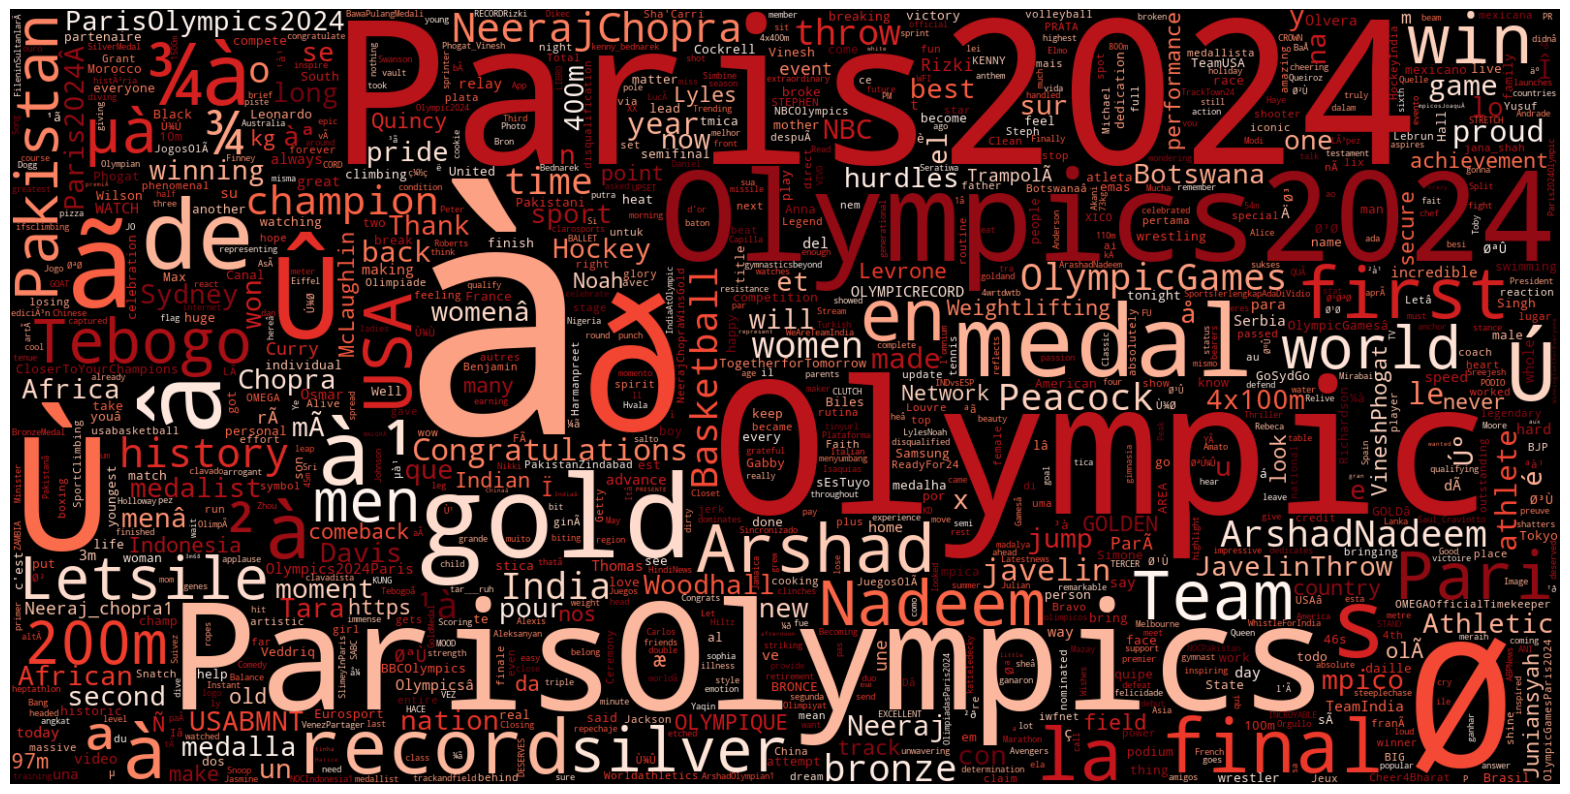

In [74]:
plt.figure(figsize=(20, 20))
wc = WordCloud(max_words=1000, width=1600, height=800, collocations=False, colormap='Reds').generate(" ".join(data_neg))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off") 
plt.show()

In [76]:
def remove_corrupted_text(text):
    """
    Cleans the input text by:
    - Removing non-ASCII characters
    - Removing sequences of repeated characters
    - Removing special symbols and corrupted characters
    - Keeping only English alphabet, digits, and some punctuation
    """
    if not isinstance(text, str):
        return ''

    # Remove non-ASCII characters
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # Remove repeated characters (e.g., "û û" becomes " ")
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # Remove special symbols or corrupted characters
    text = re.sub(r'[^\w\s,.!?\'"-]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [77]:
# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english') + ['ø³','ø', 'ù'])
lemmatizer = WordNetLemmatizer()

In [78]:
def replace_emojis(text):
    """
    Converts emojis in the text to their corresponding word descriptions.
    """
    return emoji.demojize(text, delimiters=(" ", " "))

In [79]:
def lemmatize_tweet(text):
    # Remove corrupted text
    text = remove_corrupted_text(text)

    # Convert emojis to words
    text = replace_emojis(text)

    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags (keep the text after the #)
    text = re.sub(r'#', '', text)
    # Remove special characters like "&quot;"
    text = re.sub(r'&\w+;', '', text)
    # Remove punctuation
    text = "".join([char for char in text if char not in string.punctuation])
    # Tokenize text
    tokens = re.split('\W+', text.lower())
    # Remove stopwords and lemmatize the tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    # Remove extra white spaces
    tokens = [word.strip() for word in tokens if word.strip() != '']
    # Remove numbers
    tokens = [word for word in tokens if not word.isdigit()]
    # Tag parts of speech
    pos_tags = nltk.pos_tag(tokens)
    # Filter tokens to retain only nouns, adjectives, verbs and adverbs
    important_pos = {'NN', 'NNS', 'NNP', 'NNPS', 'JJ', 'JJR', 'JJS', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'RB', 'RBR', 'RBS'}
    tokens = [word for word, tag in pos_tags if tag in important_pos]

    return tokens

In [80]:
def join_text(tokens):
    """
    This function takes a list of tokens (words) and returns them as a single string.
    Each token is separated by a space.
    """
    return " ".join(tokens)

In [81]:
# Download the Punkt sentence tokenizer
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Janani\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [85]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Janani\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [86]:
# Apply the preprocessing function to the entire Tweet_Content column
df['Lemmatized_Tweets'] = df['Tweet_Content'].apply(lambda x: join_text(lemmatize_tweet(x)))
from nltk.tokenize import word_tokenize

In [87]:
# Ensure the 'clean_tweet' column contains strings
df['Lemmatized_Tweets'] = df['Lemmatized_Tweets'].astype(str)

In [91]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Janani\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Janani\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [92]:
# Tokenizing the 'clean_tweet' column
df['Clean_Tweets'] = df['Lemmatized_Tweets'].apply(word_tokenize)

In [97]:
#Check if the corrupted words are still there in row 1000
df['Clean_Tweets'].iloc[1490]

['neeraj',
 'chopra',
 'gold',
 'medal',
 'olympics',
 'nominated',
 'world',
 'athlete',
 'year',
 'matter',
 'great',
 'pride',
 'country',
 'india',
 'many',
 'many',
 'congratulation',
 'gold',
 'medalneerajchoprawinsgoldolympics2024',
 'gold',
 'neerajchopra']

In [98]:
df.dropna(inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12078 entries, 0 to 14461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Category                  12078 non-null  object        
 1   Keyword                   12078 non-null  object        
 2   Tweet_Timestamp           12078 non-null  datetime64[ns]
 3   Tweet_Content             12078 non-null  object        
 4   Tweet_Number_of_Retweets  12078 non-null  float64       
 5   Tweet_Number_of_Likes     12078 non-null  float64       
 6   Tweet_Number_of_Looks     12078 non-null  float64       
 7   Lemmatized_Tweets         12078 non-null  object        
 8   Clean_Tweets              12078 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 943.6+ KB


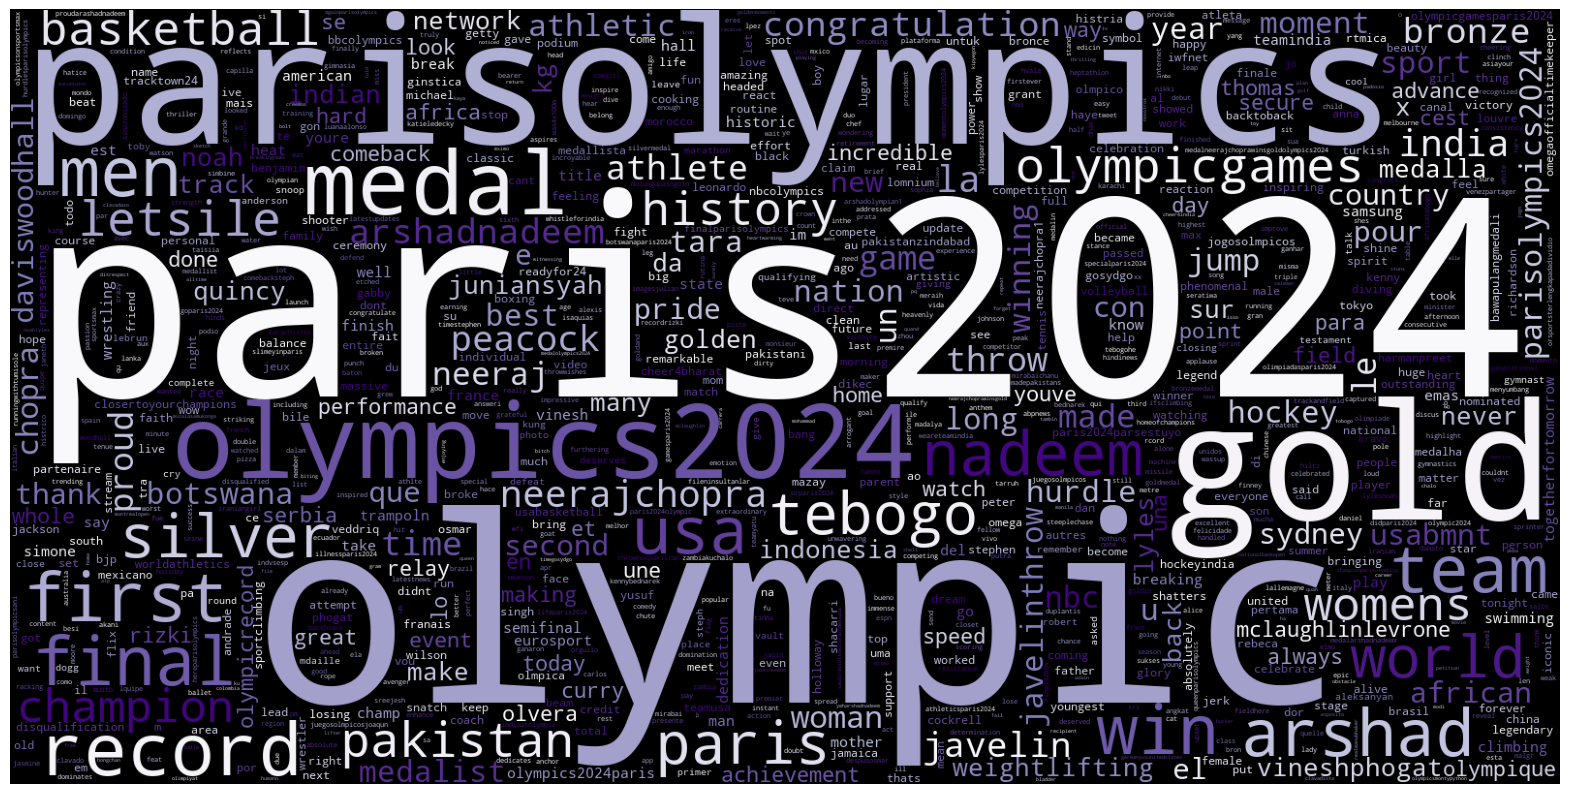

In [100]:
processedtext = df['Clean_Tweets'].tolist()

# Use all processed text (up to the length of your dataset)
data_neg = processedtext[:len(processedtext)]

# Join the tokens for each tweet into a single string
data_neg_joined = [' '.join(tokens) for tokens in data_neg]

plt.figure(figsize=(20, 20))
# Pass the joined strings to generate()
wc = WordCloud(max_words=1000, width=1600, height=800,
               collocations=False, colormap='Purples').generate(" ".join(data_neg_joined))
plt.imshow(wc)
plt.axis('off') 
plt.show()

In [101]:
# Save the DataFrame to a new CSV file
df.to_csv('cleaned-sentiments.csv', index=False)

In [102]:
# Load the clean dataset to see if its actually clean
df = pd.read_csv('cleaned-sentiments.csv')
df.dropna(inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12064 entries, 0 to 12077
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Category                  12064 non-null  object 
 1   Keyword                   12064 non-null  object 
 2   Tweet_Timestamp           12064 non-null  object 
 3   Tweet_Content             12064 non-null  object 
 4   Tweet_Number_of_Retweets  12064 non-null  float64
 5   Tweet_Number_of_Likes     12064 non-null  float64
 6   Tweet_Number_of_Looks     12064 non-null  float64
 7   Lemmatized_Tweets         12064 non-null  object 
 8   Clean_Tweets              12064 non-null  object 
dtypes: float64(3), object(6)
memory usage: 942.5+ KB
